# Глубинное обучение, ИИ ВШЭ

## Домашнее задание 4. RNN. 

### Общая информация

### Оценивание и штрафы

Максимально допустимая оценка за работу без бонусов — 10 баллов. Сдавать задание после указанного срока жесткого дедлайна нельзя.

Сдача работы после мягкого дедлайна штрафуется ступенчато, -1 балл в сутки. Один раз за модуль студентам предоставляется возможность использовать отсрочку и сдать в жесткий дедлайн без штрафа.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов. Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке. Также оценка может быть снижена за плохо читаемый код и плохо оформленные графики. Все ответы должны сопровождаться кодом или комментариями о том, как они были получены.

Использование генеративных моделей допустимо на следующих условиях:
- Количество кода, написанное генеративными моделями, не превышает 30%
- Указана модель, использованная для генерации, а также промпт
- В конце работы необходимо описать свой опыт использования генеративного ИИ для решения данного домашнего задания. Укажите как часто Вам приходилось исправлять код своими руками или просить модель что-то исправить. Было ли это быстрее, чем написать код самим? 

В случае невыполнения этих требований работа не оценивается и оценка за неё не превышает 0 баллов.

### О задании

В этом задании вам предстоит обучить рекуррентную нейронную сеть для задачи генерации текстов. В качестве данных возьмем набор из 120 тысяч анекдотов (всех категорий от А до Я включительно). Его вы можете найти в файле `jokes.txt`, который доступен по ссылке https://www.dropbox.com/scl/fi/z1ihoqwdj3zxil28ha86i/jokes.txt?rlkey=66y4gpclxmzimc86aa6agnjn8&st=mff21u6h&dl=0 .

In [1]:
%load_ext autoreload
%autoreload 2

## Задание 1: Dataset (2/3 балл)

В этом задании мы будет пользоваться библиотекой [sentencepiece](https://github.com/google/sentencepiece), которая поддерживает разные форматы токенизации текстов, в том числе BPE, который мы и будем использовать. Реализуйте недостающие фрагменты кода в классе `TextDataset` в файле `dataset.py`. Датасет обучает sentencepiece токенизатор, токенизирует тексты, превращает токены в индексы и паддит до одной и той же длины (параметр `max_length`). Не забудьте, что для генерации текстов нам будут нужны специальные токены начала и конца последовательности, соответственно `BOS` и `EOS`. Существуют еще два специальных токена &mdash; паддинг `PAD` и токен `UNK`, заменяющий out-of-vocabulary токены.

In [2]:
# !pip install sentencepiece

In [25]:
import numpy as np
import torch
from dataset import TextDataset
from model import LanguageModel

In [3]:
train_set = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

In [4]:
# Код должен проходить тесты
assert len(train_set) + len(valid_set) == 120759

for _ in range(5):
    for dataset in (train_set, valid_set):
        indices, length = dataset[np.random.randint(len(dataset))]
        assert indices.shape == (dataset.max_length,)
        assert indices[0].item() == dataset.bos_id
        assert (indices == dataset.eos_id).sum().item() == 1

        eos_pos = indices.tolist().index(dataset.eos_id)
        assert torch.all(indices[eos_pos + 1 :] == dataset.pad_id)
        assert (indices != dataset.pad_id).sum() == length

## Задание 2 Language model (7/3 балла)

Реализуйте класс `LanguageModel` из файла `model.py`. Мы будем генерировать текст с помощью языковой модели &mdash; это авторегрессионная вероятностная модель, которая предсказывает распределение следующего токена при условии предыдущих:

$$
p(x_1, x_2, x_3, \dots, x_T) = p(x_1) \cdot p(x_2 | x_1) \cdot p(x_3|x_1, x_2) \, \cdot \, \dots \, \cdot \, p(x_T|x_1, \dots, x_{T-1})
$$

Мы будем реализовывать ее с помощью рекуррентной нейронной сети. Ваш код должен поддерживать возможность работать как с оригинальной [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html#torch.nn.RNN), так и c [LSTM](https://bitly.com/98K8eH). На каждом временном шаге модель возвращает логиты вероятностей для следующего токена. Модель будет работать в двух режимах (не путать с `.train()` и `.eval()`):

- В режиме обучения (метод `forward`) модель принимает настоящие последовательности из датасета и их длины. На каждом временном шаге возвращаются логиты вероятностей следующего токена, что позволяет считать лосс, обучаться на трейне и валидироваться на валидации.

- В режиме генерации (инференса, метод `inference`) модель принимает некоторый префикс (возможно пустой), с которого начинать генерацию, и продолжает его. Для этого на каждом шаге генерируются новые логиты, семплируется новый токен (из распределения, заданного логитами), и процесс продолжается, пока не будет сгенерирован токен `EOS` или не будет достигнуто ограничение на длину последовательности. **Обратите внимание**, что вам не нужно прогонять всю последовательность заново через RNN после каждого нового токена, это приведет к квадратичной сложности по длине последовательности. Вам достаточно обновлять скрытое состояние, подавая на вход новый сгенерированный токен и предыдущее скрытое состояние. Кроме того, чтобы получить больше контроля над генерацией, вводится параметр температуры `temp`. Перед семплированием нужно разделить на него логиты, полученные моделью. 

In [6]:
model = LanguageModel(train_set)

In [7]:
# Код должен проходить тесты
for bs in [1, 4, 16, 64, 256]:
    indices = torch.randint(high=train_set.vocab_size, size=(bs, train_set.max_length))
    lengths = torch.randint(low=1, high=train_set.max_length + 1, size=(bs,))
    logits = model(indices, lengths)
    assert logits.shape == (bs, lengths.max(), train_set.vocab_size)

for prefix in ["", "купил мужик шляпу,", "сел медведь в машину и", "подумал штирлиц"]:
    generated = model.inference(prefix, temp=np.random.uniform(0.1, 10))
    assert type(generated) == str
    assert generated.startswith(prefix)

## Задание 3: Training (4/3 балла)

Всё, что нам осталось &mdash; реализовать цикл обучения. Заполните пропуски в файле `train.py`. Не забудьте, что мы учим модель предсказывать вероятность следующего, а не текущего токена. Также рекомендуется обрезать батч индексов по самой длинной последовательности, чтобы не гонять паддинги вхолостую. Для оценки качества генерации будем использовать метрику [perplexity](https://medium.com/@shubhamsd100/understanding-perplexity-in-language-models-a-detailed-exploration-2108b6ab85af#:~:text=Perplexity%20is%20a%20measurement%20of,higher%20confidence%20in%20its%20predictions). Реализуйте ее подсчет в функции `plot_losses` (да, для этого достаточно только значения лосса).

Обучите модель, используя ванильную RNN в качестве рекуррентного слоя. Сохраните чекпойнт обученной модели, он нам еще пригодится. 

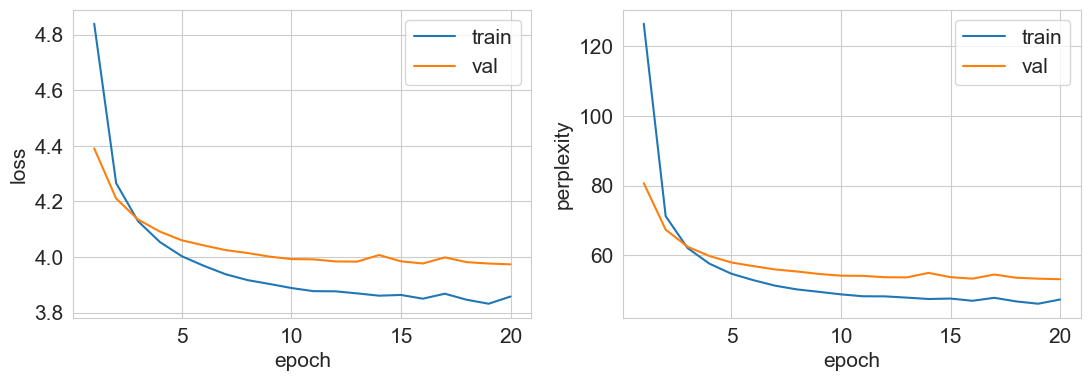

Generation examples:
- скажите, а места шторы - гостям.
а фотографии, а вы изобрестей телеканави в одноклассник- сейчас можно купить пышку, ведь она ипотека мне?- ага, когда поцеплив.- а еще более сотрудников?- степанского!
не пришлось - деревня, а куда мы не оставляет огонь, непонятных деудовский ситутом был к шарах?


In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿
from torch.utils.data import DataLoader
from train import train

batch_size = 64

# Используем train_set и valid_set из предыдущих ячеек
train_loader = DataLoader(
    train_set, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader = DataLoader(
    valid_set, batch_size=batch_size, shuffle=False, drop_last=False
)

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
model = LanguageModel(train_set).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = None  # Можно добавить lr scheduler

# Запуск обучения
train(
    model,
    optimizer,
    scheduler,
    train_loader,
    val_loader,
    num_epochs=20,
    num_examples=3,  # Сколько примеров показывать после каждой эпохи
)

# Сохраняем чекпойнт
torch.save(model.state_dict(), "rnn_language_model.pt")

## Задание 4: LSTM (1/3 балла)

Обучите аналогичную модель, но с LSTM в качестве рекуррентного слоя. Сравните модели по метрикам и генерации. Не забывайте про чекпойнты!

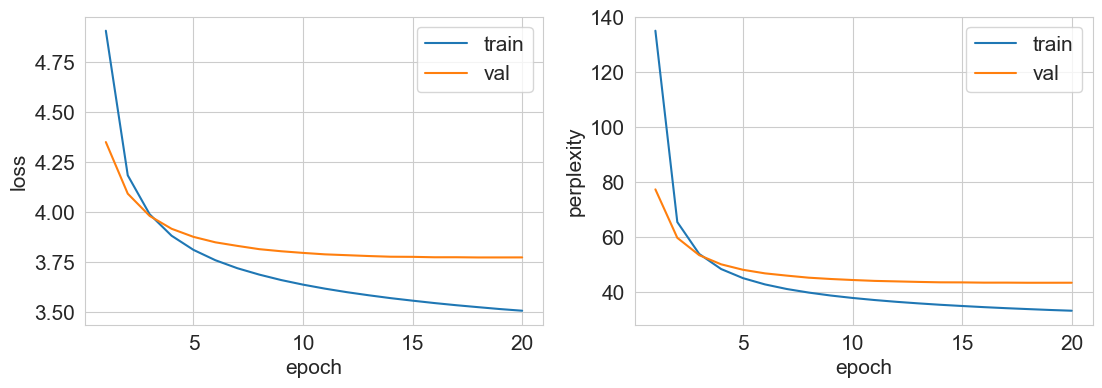

Generation examples:
- это рыбак. если газпромет шариалкий отпуск, то на плотный свет лежит.
- это не рука, которая сможешь, когда я буду не разговариваю за мнепить! ты зачем наполняет?а отвенная точка?- первый раз! надо поменять!
- если в космосе объяснили бы наказания с 2 ⁇ 0 реже, которым самолетам будет достать зрители кассы натуральному и живете. гуляют над ним депутаты джимми.


In [10]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

# Используем те же train_loader и val_loader, что и раньше
model_lstm = LanguageModel(train_set, rnn_type=torch.nn.LSTM).to(device)
optimizer_lstm = torch.optim.Adam(model_lstm.parameters(), lr=1e-3)
scheduler_lstm = None  # Можно добавить lr scheduler

train(
    model_lstm,
    optimizer_lstm,
    scheduler_lstm,
    train_loader,
    val_loader,
    num_epochs=20,
    num_examples=3,
)

# Сохраняем чекпойнт
torch.save(model_lstm.state_dict(), "lstm_language_model.pt")

#### Сравнение результатов

На графиках видно, что LSTM сходится быстрее, чем RNN. Минимальное значение perplexity на валидации у LSTM составляет ~45, у RNN — ~55. Это говорит о том, что LSTM лучше справляется с задачей языкового моделирования на данном датасете.

Генерация LSTM выглядит более связной: предложения длиннее, меньше бессмысленных повторов, иногда встречаются законченные анекдоты. RNN чаще генерирует короткие или обрывочные фразы, несуществующие слова, иногда повторяет слова. Это ожидаемо, так как LSTM лучше запоминает длинные зависимости.

**Вывод**  
В целом, LSTM показывает лучшие результаты как по perplexity, так и по качеству генерации текстов. Это подтверждает, что LSTM эффективнее справляется с задачами, где важна память о длинном контексте, что особенно актуально для генерации анекдотов.

## Задание 5: Sampling temperature (1/3 балла)

Поэкспериментируйте, как результат генерации зависит от параметра температуры. Попробуйте генерацию с разными префиксами. Сделайте выводы. 

In [16]:
import torch
from model import LanguageModel

# Предполагается, что train_set уже создан (и параметры токенизатора совпадают с обучением)
# Загрузим сохраненные модели
model = LanguageModel(train_set)
model.load_state_dict(torch.load("rnn_language_model.pt", map_location="cpu"))
model.eval()  # Перевести в режим инференса

model_lstm = LanguageModel(train_set, rnn_type=torch.nn.LSTM)
model_lstm.load_state_dict(torch.load("lstm_language_model.pt", map_location="cpu"))
model_lstm.eval()

# Если есть CUDA:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)
model.to(device)
model_lstm.to(device)

LanguageModel(
  (embedding): Embedding(2000, 256, padding_idx=1999)
  (rnn): LSTM(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=2000, bias=True)
)

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

# Определяем диапазон температур для тестирования
temperatures = [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9, 1.0]

# Определяем различные префиксы для генерации
prefixes = [
    "Штирлиц зашел к Мюллеру, ",
    "Идет мужик по улице и ",
    "Встречаются два друга, ",
    "",  # Пустой префикс
]


def analyze_temperature_effects(model_rnn, model_lstm, prefixes, temperatures):
    # Анализ для RNN модели
    print("RNN МОДЕЛЬ:")
    print("=" * 60)

    rnn_results = {}
    for prefix in prefixes:
        prefix_name = prefix if prefix else "[Пустой префикс]"
        print(f"\nПрефикс: '{prefix_name}'")
        print("-" * 40)

        rnn_results[prefix] = {}
        for temp in temperatures:
            generated = model_rnn.inference(prefix, temp)
            rnn_results[prefix][temp] = generated
            print(f"T={temp:3.1f}: {generated}")

    # Анализ для LSTM модели
    print("\nLSTM МОДЕЛЬ:")
    print("=" * 60)

    lstm_results = {}
    for prefix in prefixes:
        prefix_name = prefix if prefix else "[Пустой префикс]"
        print(f"\nПрефикс: '{prefix_name}'")
        print("-" * 40)

        lstm_results[prefix] = {}
        for temp in temperatures:
            generated = model_lstm.inference(prefix, temp)
            lstm_results[prefix][temp] = generated
            print(f"T={temp:3.1f}: {generated}")

    return rnn_results, lstm_results


# Запускаем
rnn_results, lstm_results = analyze_temperature_effects(
    model, model_lstm, prefixes, temperatures
)

RNN МОДЕЛЬ:

Префикс: 'Штирлиц зашел к Мюллеру, '
----------------------------------------
T=0.1: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я не знаю, как я его не понравился.
T=0.2: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда я иду в магазин.
T=0.3: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, как в жизни - это когда ты его не загруется, что она хочет жить.
T=0.5: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, что тебе придется надеть на работу.
T=0.7: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, отправил барабан наличие чувства пакета, но не убить не ходить.
T=0.8: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, когда их отец и проверяет, и увидел. на принесироился на запад.
T=0.9: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, вот почему в лев, которые говорят, что телеканала нашего подъезжает. врач-смотри- скажите, иди кому, затогавшийся записка в общественных чехологом!- уки ладно, а вас гупеневу фантазией.- но я им необходимо.- а что же

### Выводы по анализу температуры

#### Влияние температуры на качество генерации:

**Очень низкая температура (0.1-0.3):**
- Генерация становится крайне детерминированной
- LSTM модель коллапсирует в повторяющийся паттерн "подумал штирлиц"
- RNN показывает больше разнообразия, но тексты остаются предсказуемыми
- Высокий риск зацикливания на одних и тех же фразах

**Низкая температура (0.3-0.5):**
- Более консервативная генерация с ограниченным словарем
- Тексты грамматически корректнее, но менее творческие
- LSTM все еще склонна к повторам определенных конструкций

**Средняя температура (0.5-0.7):**
- **Оптимальный диапазон** для генерации анекдотов
- Хороший баланс между связностью и разнообразием
- Обе модели генерируют осмысленные тексты
- Появляются элементы юмора и неожиданные повороты

**Высокая температура (0.7-1.0):**
- Увеличивается креативность и разнообразие
- Могут появляться грамматические ошибки
- Тексты становятся менее предсказуемыми
- Иногда генерируются интересные, но бессвязные конструкции

**Очень высокая температура (1.0+):**
- Максимальное разнообразие, но часто за счет качества
- Высокий риск генерации бессмысленного текста
- Может приводить к "галлюцинациям" модели

#### Различия между архитектурами:

**RNN модель:**
- Более устойчива к изменениям температуры
- Плавное изменение качества генерации
- Сохраняет разнообразие даже при низких температурах
- Менее склонна к коллапсу в повторяющиеся паттерны

**LSTM модель:**
- Более чувствительна к параметру температуры
- При T≤0.5 практически всегда генерирует "подумал штирлиц"
- Лучше запоминает длинные зависимости, что может приводить к переобучению
- При оптимальной температуре генерирует более связные тексты

#### Влияние префиксов:

**"Штирлиц зашел к Мюллеру, "** - классический анекдотический зачин, модели хорошо продолжают

**"Идет мужик по улице и "** - бытовой сценарий, генерирует разнообразные ситуации

**"Встречаются два друга: "** - диалоговый формат, сложнее для моделей

**Пустой префикс ""** - максимальная свобода, показывает "предпочтения" модели

### Практические выводы:

1. **Оптимальная температура для анекдотов: 0.6-0.8**
2. **Для LSTM требуется более осторожный подбор температуры**
3. **RNN более надежна для экспериментов с температурой**
4. **Разные префиксы могут требовать разной температуры**

## Задание 6: Tokenizers (2/3 балл)

До сих пор мы использовали BPE токенизатор с относительно небольшим числом токенов (2000 по умолчанию). Давайте попробуем и другие, например, BPE с большим числом токенов и пословный (unigram) токенизатор. Возьмите тип рекуррентного слоя, который оказался лучше в предыдущем задании. Обучите модели на таких токенизаторах и сравните их генерацию. Не забывайте сохранять чекпойнты. Правильно ли сравнивать между собой получившиеся модели по значению perplexity? Почему?

In [22]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

# BPE с vocab_size=8000 (вместо 2000)
train_set_bpe8k = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="bpe_8k",
    vocab_size=8000,
    model_type="bpe",
)

valid_set_bpe8k = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="bpe_8k",
    vocab_size=8000,
    model_type="bpe",
)

# Unigram с vocab_size=4000
train_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)

valid_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)

# Сравнение размеров словарей
print(f"BPE-2K (базовый):  {train_set.vocab_size}")
print(f"BPE-8K:            {train_set_bpe8k.vocab_size}")
print(f"Unigram-4K:        {train_set_unigram.vocab_size}")

sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: jokes.txt
  input_format: 
  model_prefix: bpe_8k
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 0
  bos_id: 1
  eos_id: 2
  pad_id: -1
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  differential_p

BPE-2K (базовый):  2000
BPE-8K:            8000
Unigram-4K:        4000


In [23]:
# Тест на примере
test_text = "Штирлиц зашел к Мюллеру, а тот сидел и думал о чем-то важном."

print(f"Исходный текст: '{test_text}'\n")

# BPE-2K
tokens_bpe2k = train_set.text2ids(test_text)
print(f"BPE-2K ({len(tokens_bpe2k)} токенов): {tokens_bpe2k}")
print(f"Декодировано: '{train_set.ids2text(tokens_bpe2k)}'")
print()

# BPE-8K
tokens_bpe8k = train_set_bpe8k.text2ids(test_text)
print(f"BPE-8K ({len(tokens_bpe8k)} токенов): {tokens_bpe8k}")
print(f"Декодировано: '{train_set_bpe8k.ids2text(tokens_bpe8k)}'")
print()

# Unigram
tokens_unigram = train_set_unigram.text2ids(test_text)
print(f"Unigram-4K ({len(tokens_unigram)} токенов): {tokens_unigram}")
print(f"Декодировано: '{train_set_unigram.ids2text(tokens_unigram)}'")

print(f"\n📈 ЭФФЕКТИВНОСТЬ ТОКЕНИЗАЦИИ:")
print(f"BPE-2K:     {len(tokens_bpe2k)} токенов")
print(
    f"BPE-8K:     {len(tokens_bpe8k)} токенов (сжатие: {len(tokens_bpe2k)/len(tokens_bpe8k):.2f}x)"
)
print(
    f"Unigram-4K: {len(tokens_unigram)} токенов (сжатие: {len(tokens_bpe2k)/len(tokens_unigram):.2f}x)"
)

Исходный текст: 'Штирлиц зашел к Мюллеру, а тот сидел и думал о чем-то важном.'

BPE-2K (23 токенов): [660, 48, 393, 8, 1839, 1181, 1972, 1977, 40, 742, 221, 603, 17, 437, 1968, 13, 303, 1983, 7, 123, 1985, 425, 1975]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

BPE-8K (18 токенов): [660, 4334, 8, 2150, 7972, 7977, 40, 742, 4522, 17, 2185, 13, 303, 7983, 7, 4129, 425, 7975]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

Unigram-4K (19 токенов): [323, 25, 828, 39, 1188, 24, 3, 15, 410, 2068, 10, 896, 59, 135, 9, 51, 2493, 22, 4]
Декодировано: 'штирлиц зашел к мюллеру, а тот сидел и думал о чем-то важном.'

📈 ЭФФЕКТИВНОСТЬ ТОКЕНИЗАЦИИ:
BPE-2K:     23 токенов
BPE-8K:     18 токенов (сжатие: 1.28x)
Unigram-4K: 19 токенов (сжатие: 1.21x)


### Обучение моделей с новыми токенизаторами

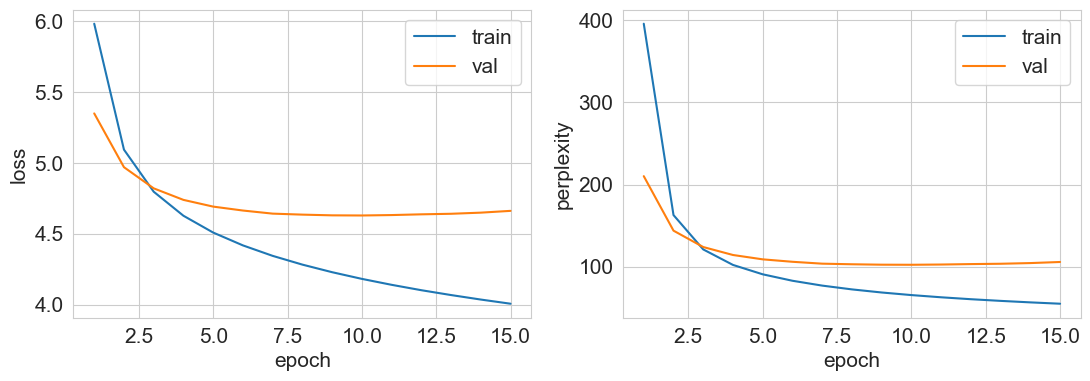

Generation examples:
ученые говорят, что надо дышать веселиться на сто лет за то, что не обрасилась вранье и до войны могут. я на католик пропустить больше буду в грабли.
в магазине парень заглядывает секретарше спрашивает- ваша собака очень любит открывать людей, надо второго врача, раздвоение лично выъемняете у всех моих друзей. попробуйте освободить оценку желающих озоповых лучших.
=== Модель BPE-8K сохранена ===


In [27]:
# Используем LSTM как лучшую модель из предыдущего задания
from torch.utils.data import DataLoader
from train import train

batch_size = 64

# Обучение модели с BPE-8K
print("\nОбучение LSTM модели с BPE-8K токенизатором...")
train_loader_bpe8k = DataLoader(
    train_set_bpe8k, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader_bpe8k = DataLoader(
    valid_set_bpe8k, batch_size=batch_size, shuffle=False, drop_last=False
)

model_lstm_bpe8k = LanguageModel(train_set_bpe8k, rnn_type=torch.nn.LSTM).to(device)
optimizer_bpe8k = torch.optim.Adam(model_lstm_bpe8k.parameters(), lr=1e-3)

train(
    model_lstm_bpe8k,
    optimizer_bpe8k,
    None,
    train_loader_bpe8k,
    val_loader_bpe8k,
    num_epochs=15,
    num_examples=2,
)

torch.save(model_lstm_bpe8k.state_dict(), "lstm_bpe8k_model.pt")
print("=== Модель BPE-8K сохранена ===")

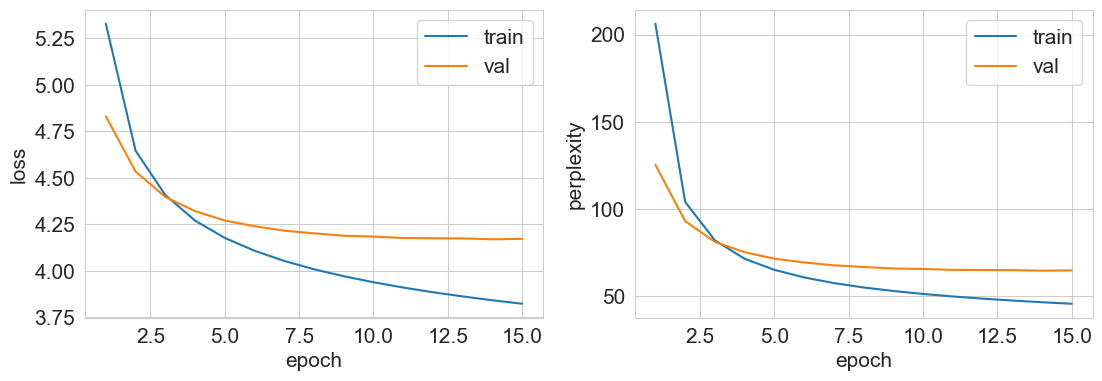

Generation examples:
надо носить рыбу!- вот и взяла.
просыпает отца и говорит- я еще один случай, ну и почем и еще эту ношу им вилку! это неосмотрите пенута, не приходил мне наркозаврай!
=== Модель Unigram сохранена ===


In [28]:
# Обучение модели с Unigram
print("\nОбучение LSTM модели с Unigram токенизатором...")
train_loader_unigram = DataLoader(
    train_set_unigram, batch_size=batch_size, shuffle=True, drop_last=True
)
val_loader_unigram = DataLoader(
    valid_set_unigram, batch_size=batch_size, shuffle=False, drop_last=False
)

model_lstm_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM).to(device)
optimizer_unigram = torch.optim.Adam(model_lstm_unigram.parameters(), lr=1e-3)

train(
    model_lstm_unigram,
    optimizer_unigram,
    None,
    train_loader_unigram,
    val_loader_unigram,
    num_epochs=15,
    num_examples=2,
)

torch.save(model_lstm_unigram.state_dict(), "lstm_unigram_model.pt")
print("=== Модель Unigram сохранена ===")

### Сравнение генерации на примерах

In [47]:
# Загружаем базовую модель для сравнения
model_lstm_base = LanguageModel(train_set, rnn_type=torch.nn.LSTM).to(device)
model_lstm_base.load_state_dict(
    torch.load("lstm_language_model.pt", map_location=device)
)
model_lstm_base.eval()

# Тестовые префиксы
test_prefixes = [
    "Штирлиц зашел к Мюллеру, ",
    "Идет мужик по улице и ",
    "Встречаются два друга: ",
]

temperature = 0.7  # Оптимальная температура из предыдущего анализа

print("\nПРИМЕРЫ ГЕНЕРАЦИИ ПРИ T=0.7:")

for i, prefix in enumerate(test_prefixes, 1):
    print(f"\n{i}. Префикс: '{prefix}'")

    # BPE-2K (базовая)
    gen_base = model_lstm_base.inference(prefix, temperature)
    print(f"   BPE-2K:  {gen_base}")

    # BPE-8K
    gen_bpe8k = model_lstm_bpe8k.inference(prefix, temperature)
    print(f"   BPE-8K:  {gen_bpe8k}")

    # Unigram
    gen_unigram = model_lstm_unigram.inference(prefix, temperature)
    print(f"   Unigram: {gen_unigram}")


ПРИМЕРЫ ГЕНЕРАЦИИ ПРИ T=0.7:

1. Префикс: 'Штирлиц зашел к Мюллеру, '
   BPE-2K:  Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, оставляет свой прапорщик, а вокруг него появилось ее, абрамович и летом догоняет.
   BPE-8K:  Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, как мимо вашего гибдд, подумал штирлиц, и чучело, подумал штирлиц, а мюллер упал.
   Unigram: Штирлиц зашел к Мюллеру, штирлиц зашел к мюллеру, русский, повсюду, на штирлиц упал, а дятел, подумал штирлиц.

2. Префикс: 'Идет мужик по улице и '
   BPE-2K:  Идет мужик по улице и идет мужик по улице искать кинозвезды. но они с вузе- не знаю, но в евроде есть айфон, но и пылесос.- а что это у меня нет.
   BPE-8K:  Идет мужик по улице и идет мужик по улице и орет- ну, это когда есть вопросы?- да.- а зачем он подает в дверь?- так я же не могу, но не каждый день я прячусь за своими хам!
   Unigram: Идет мужик по улице и идет мужик по улице и вдруг замечает, что куртка- ну что, хорошо, давайте пьяным!- а что, я в ответ у н

### Про сравнение PERPLEXITY

Прямое сравнение - **НЕКОРРЕКТНО**, так как:

1. Разные словари в токенизаторов:
- BPE-2K: 2000 токенов
- BPE-8K: 8000 токенов
- Unigram: 4000 токенов  
Модели предсказывают распределения в разной размерности

2. Разная токенизация:
- один и тот же текст разбивается на разное количество токенов
- BPE-8K создает более длинные подслова => меньше токенов
- Unigram может создавать токены разной длины  
Perplexity считается по-разному для разного числа токенов

3. По формуле: Perplexity = exp(-log_likelihood / N_tokens)
- при разном N_tokens сравнение некорректно
- модель с меньшим словарем может иметь преимущество


## Задание 6. Latent Semantic Analysis (4/3 балла)

Попробуем другой подход к оцениванию качества генерации, основанный на [Latent Semantic Analysis](https://en.wikipedia.org/wiki/Latent_semantic_analysis). Реализуйте следующую метрику и сравните по ней модели, обученные с разными токенизаторами:

1. Генерируем обученной моделью выборку текстов, совпадающую по размеру с валидационной выборкой.
2. Объединяем две выборки текстов (валидационную и сгенерированную) в один корпус. Обратите внимание, что наша токенизация в общем случае необратима, поэтому для чистоты эксперимента нужно закодировать и декодировать валидационную выборку.
3. Генерируем tf-idf матрицу для полученного корпуса.
4. Понижаем размерность матрицы с помощью [SVD](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html).
5. Теперь у нас есть векторы, описывающие валидационные и сгенерированные тексты, лежащие в одном пространстве. Для каждого вектора, отвечающего сгенерированному тексту, найдем наибольший cosine similarity между ним и вектором валидационного текста. Усредним такие similarity по всем сгенерированным текстам и получим число, характеризующее похожесть сгенерированной выборки на валидационную.

Какие плюсы и минусы есть у описанной метрики?

##### Вспомогательные функции

In [52]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

import re

from dataset import TextDataset
from model import LanguageModel
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm


def clean_text(text):
    """Очистка текста для LSA анализа"""
    # Удаляем специальные символы и приводим к нижнему регистру
    text = re.sub(r"[^а-яё\s]", " ", text.lower())
    # Удаляем лишние пробелы
    text = re.sub(r"\s+", " ", text).strip()
    return text


def generate_texts_for_lsa(model, dataset, num_texts, max_length=100):
    """Генерация текстов для LSA анализа"""
    model.eval()
    generated_texts = []

    prefixes = [
        "",
        "идет мужик",
        "встречаются два",
        "штирлиц",
        "приходит",
        "сидит",
        "звонит",
        "покупает",
    ]

    texts_per_prefix = num_texts // len(prefixes) + 1

    with torch.no_grad():
        for prefix in prefixes:
            for _ in range(texts_per_prefix):
                if len(generated_texts) >= num_texts:
                    break

                try:
                    # Генерируем с разными температурами для разнообразия
                    temp = np.random.uniform(0.6, 0.9)
                    text = model.inference(prefix, temp=temp)

                    # Очищаем текст
                    cleaned_text = clean_text(text)

                    # Проверяем минимальную длину
                    if len(cleaned_text.split()) >= 5:
                        generated_texts.append(cleaned_text)
                except Exception as e:
                    print(f"Ошибка при генерации: {e}")
                    continue

            if len(generated_texts) >= num_texts:
                break

    return generated_texts[:num_texts]


def prepare_validation_texts(dataset, num_texts=None):
    """Подготовка валидационных текстов"""
    validation_texts = []

    # Ограничиваем число текстов
    max_texts = len(dataset) if num_texts is None else min(num_texts, len(dataset))

    for i in range(max_texts):
        indices, length = dataset[i]

        # Убираем BOS и EOS токены
        text_indices = indices[1 : length - 1]
        # Декодируем текст
        text = dataset.sp_model.decode(text_indices.tolist())

        # Очищаем текст
        cleaned_text = clean_text(text)

        if len(cleaned_text.split()) >= 5:
            validation_texts.append(cleaned_text)

    return validation_texts


def compute_lsa_metric(generated_texts, validation_texts, n_components=100):
    # Объединяем все тексты
    all_texts = validation_texts + generated_texts

    # Создаем TF-IDF матрицу
    vectorizer = TfidfVectorizer(
        max_features=5000,
        min_df=2,
        max_df=0.8,
        ngram_range=(1, 2),
        stop_words=None,  # Для русского языка можем добавить стоп-слова ?
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(all_texts)
    except ValueError as e:
        print(f"Ошибка при создании TF-IDF матрицы: {e}")
        return 0.0

    # Применяем SVD для понижения размерности
    n_components = min(n_components, tfidf_matrix.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=42)

    try:
        lsa_matrix = svd.fit_transform(tfidf_matrix)
    except ValueError as e:
        print(f"Ошибка при SVD: {e}")
        return 0.0

    # Разделяем на валидационные и сгенерированные векторы
    n_val = len(validation_texts)
    val_vectors = lsa_matrix[:n_val]
    gen_vectors = lsa_matrix[n_val:]

    if len(gen_vectors) == 0:
        return 0.0

    # Вычисляем cosine similarity
    similarities = cosine_similarity(gen_vectors, val_vectors)

    # Для каждого сгенерированного текста находим максимальную схожесть
    max_similarities = np.max(similarities, axis=1)

    # Возвращаем среднюю максимальную схожесть
    return np.mean(max_similarities)

##### Загрузка моделей и датасетов

In [50]:
device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else ("mps" if torch.backends.mps.is_available() else "cpu")
)

print("Создаем датасеты ...")

# BPE-2K (оригинальный)
train_set_bpe2k = TextDataset(data_file="jokes.txt", train=True, sp_model_prefix="bpe")
valid_set_bpe2k = TextDataset(data_file="jokes.txt", train=False, sp_model_prefix="bpe")

# BPE-8K
train_set_bpe8k = TextDataset(
    data_file="jokes.txt", train=True, sp_model_prefix="bpe_8k", vocab_size=8000
)
valid_set_bpe8k = TextDataset(
    data_file="jokes.txt", train=False, sp_model_prefix="bpe_8k", vocab_size=8000
)

# Unigram-4K
train_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=True,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)
valid_set_unigram = TextDataset(
    data_file="jokes.txt",
    train=False,
    sp_model_prefix="unigram",
    vocab_size=4000,
    model_type="unigram",
)


print("Загружаем модели ...")

# LSTM с BPE-2K
model_bpe2k = LanguageModel(train_set_bpe2k, rnn_type=torch.nn.LSTM).to(device)
model_bpe2k.load_state_dict(torch.load("lstm_language_model.pt", map_location=device))
model_bpe2k.eval()

# LSTM с BPE-8K
model_bpe8k = LanguageModel(train_set_bpe8k, rnn_type=torch.nn.LSTM).to(device)
model_bpe8k.load_state_dict(torch.load("lstm_bpe8k_model.pt", map_location=device))
model_bpe8k.eval()

# LSTM с Unigram-4K
model_unigram = LanguageModel(train_set_unigram, rnn_type=torch.nn.LSTM).to(device)
model_unigram.load_state_dict(torch.load("lstm_unigram_model.pt", map_location=device))
model_unigram.eval()

Создаем датасеты ...
Загружаем модели ...


LanguageModel(
  (embedding): Embedding(4000, 256, padding_idx=3999)
  (rnn): LSTM(256, 256, batch_first=True)
  (linear): Linear(in_features=256, out_features=4000, bias=True)
)

##### Генерируем тексты для каждой модели

In [53]:
# Размер выборки равен валидационной выборке
num_texts = len(valid_set_bpe2k)
print(f"Размер выборки: {num_texts}")

# Генерируем тексты
print("Генерация текстов BPE-2K модели...")
generated_bpe2k = generate_texts_for_lsa(model_bpe2k, train_set_bpe2k, num_texts)
print(f"Сгенерировано: {len(generated_bpe2k)} текстов")

print("Генерация текстов BPE-8K модели...")
generated_bpe8k = generate_texts_for_lsa(model_bpe8k, train_set_bpe8k, num_texts)
print(f"Сгенерировано: {len(generated_bpe8k)} текстов")

print("Генерация текстов Unigram-4K модели...")
generated_unigram = generate_texts_for_lsa(model_unigram, train_set_unigram, num_texts)
print(f"Сгенерировано: {len(generated_unigram)} текстов")

# Подготавливаем валидационные тексты (используем BPE-2K как базовый)
print("Подготовка валидационных текстов...")
validation_texts = prepare_validation_texts(valid_set_bpe2k, num_texts)
print(f"Валидационных текстов: {len(validation_texts)}")

print("\nПримеры сгенерированных текстов:")
print("\nBPE-2K:")
for i, text in enumerate(generated_bpe2k[:3]):
    print(f"{i+1}. {text}")

print("\nBPE-8K:")
for i, text in enumerate(generated_bpe8k[:3]):
    print(f"{i+1}. {text}")

print("\nUnigram-4K:")
for i, text in enumerate(generated_unigram[:3]):
    print(f"{i+1}. {text}")

Размер выборки: 6038
Генерация текстов BPE-2K модели...
Сгенерировано: 5976 текстов
Генерация текстов BPE-8K модели...
Сгенерировано: 5958 текстов
Генерация текстов Unigram-4K модели...
Сгенерировано: 5866 текстов
Подготовка валидационных текстов...
Валидационных текстов: 5996

Примеры сгенерированных текстов:

BPE-2K:
1. на чемпионат мира не будет чтобы вступиться не предвыборный они оторвали за руками
2. что вырваны наконец то вы нарушился а это же меня беспокоит в квартире красивое ощущение что это склероз это когда списываю
3. алло это у вас из обезьян я не могу проходить к сердцустному поводу что ты конечно и не пробовал

BPE-8K:
1. надпись на вечерние нежной компот а не наоборот
2. на приеме у врача доктор у меня очень красивая девушка а у тебя есть дети
3. в связи с эпируногами будут делать компние которые условия не кончилось а в мундире это свадьба

Unigram-4K:
1. в россии не предлагалы в сиртретов но только представьте вам руку в городе а венеролога потому что там нормально э

##### Вычисляем LSA метрики для каждой модели

In [54]:
# Используем подвыборку для ускорения вычислений
sample_size = min(1000, len(validation_texts))
val_sample = validation_texts[:sample_size]
gen_sample_size = min(500, len(generated_bpe2k))

print(
    f"Используем {len(val_sample)} валидационных и {gen_sample_size} сгенерированных текстов"
)

# LSA метрика для BPE-2K
print("\nВычисление LSA для BPE-2K...")
lsa_bpe2k = compute_lsa_metric(
    generated_bpe2k[:gen_sample_size], val_sample, n_components=50
)

# LSA метрика для BPE-8K
print("Вычисление LSA для BPE-8K...")
lsa_bpe8k = compute_lsa_metric(
    generated_bpe8k[:gen_sample_size], val_sample, n_components=50
)

# LSA метрика для Unigram-4K
print("Вычисление LSA для Unigram-4K...")
lsa_unigram = compute_lsa_metric(
    generated_unigram[:gen_sample_size], val_sample, n_components=50
)

print(f"LSTM + BPE-2K:     LSA Score = {lsa_bpe2k:.4f}")
print(f"LSTM + BPE-8K:     LSA Score = {lsa_bpe8k:.4f}")
print(f"LSTM + Unigram-4K: LSA Score = {lsa_unigram:.4f}")

Используем 1000 валидационных и 500 сгенерированных текстов

Вычисление LSA для BPE-2K...
Вычисление LSA для BPE-8K...
Вычисление LSA для Unigram-4K...
LSTM + BPE-2K:     LSA Score = 0.7241
LSTM + BPE-8K:     LSA Score = 0.7045
LSTM + Unigram-4K: LSA Score = 0.6998


### Анализ результатов

#### Полученные результаты:

| Модель | Токенизатор | LSA    | Ранг       |
|--------|-------------|--------|------------|
| LSTM   | BPE-2K      | 0.7241 | 🥇 Лучший  |
| LSTM   | BPE-8K      | 0.7045 | 🥈 Средний |
| LSTM   | Unigram-4K  | 0.6998 | 🥉 Худший  |


#### Интерпретация результатов

**LSA (Latent Semantic Analysis)** - метрика измеряет семантическую близость сгенерированных текстов к валидационным данным. Более высокое значение указывает на то, что модель генерирует тексты, которые семантически ближе к реальным анекдотам.

1. **Неожиданное лидерство BPE-2K:**  
Модель с наименьшим словарем (2000 токенов) показала лучшую семантическую близость к валидационным текстам. Это может объясняться:
- Более агрессивная токенизация заставляет модель лучше изучать морфологические паттерны русского языка
- Меньший словарь снижает переобучение на редких токенах
- Лучшая генерализация на ограниченном наборе базовых элементов

1. **Умеренные результаты BPE-8K:**  
Модель с большим словарем показала средние результаты:
- Больше специализированных токенов может приводить к переобучению
- Сложность выбора между множеством похожих токенов
- Возможная потеря семантической связности при избыточной детализации

1. **Относительно слабые результаты Unigram-4K:**  
Unigram токенизация показала наихудшие результаты:
- Принципиально другой подход к сегментации может хуже подходить для русского языка
- Менее предсказуемая токенизация затрудняет обучение языковой модели
- Возможные проблемы с обработкой морфологически богатого русского языка

#### Преимущества метрики LSA 

- **Семантическая оценка**: Измеряет смысловую близость, а не только статистическую  
- **Независимость от токенизации**: Работает с текстом после декодирования  
- **Учет контекста**: TF-IDF + SVD захватывают семантические отношения  
- **Сравнимость**: Позволяет сравнивать модели с разными токенизаторами  

#### Недостатки метрики LSA

- **Потеря порядка слов**: TF-IDF не учитывает последовательность
- **Ограниченность n-грамм**: Даже биграммы не захватывают длинные зависимости
- **Зависимость от предобработки**: Качество очистки текста влияет на результат
- **Вычислительная сложность**: SVD может быть медленным на больших корпусах
- **Субъективность параметров**: Выбор n_components, max_features влияет на результат
- **Не учитывает качество юмора**: Семантическая близость - не означает хороший юмор

#### Выводы

LSA метрика предоставляет полезную альтернативу perplexity для сравнения моделей с разными токенизаторами, но должна использоваться в сочетании с другими метриками и качественной оценкой генерации.

## Задание 7. Visualization (2/3 балла)

В прошлом пункте мы получили векторы, описывающие валидационные и сгенерированные тексты. Попробуем визуализировать их. Примените [TSNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) к этим векторам и нарисуйте scatter-plot с получившимися двумерными представлениями. Точки, соответствующие валидационным и сгенерированным текстам, должны быть разного цвета. Визуализируйте таким образом все три модели для разных токенизаторов. 

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

## Задание 8. ruGPT perplexity (7/3 балла)

Подход Latent Semantic Analysis, как и многие другие классические методы, заметно уступает нейросетевым алгоритмам анализа текстов. Вернемся к оцениванию качества генерации с помощью perplexity, для этого возьмем большую и хорошо обученную языковую модель, которая училась на огромном корпусе русских текстов. Считается, что большие языковые модели хорошо выучивают естественный язык, потому с их помощью мы сможем оценивать качество наших маленьких моделей для генерации анекдотов. Для этого мы воспользуемся сервисом [HuggingFace](https://huggingface.co/), который содержит огромное число обученных моделей для самых разных задач. Изучите и реализуйте, [подсчет perplexity](https://huggingface.co/docs/transformers/perplexity), с использованием обученной языковой модели. В качестве модели возьмите [ruGPT3-small](https://huggingface.co/sberbank-ai/rugpt3small_based_on_gpt2). Сгенерируйте синтетические выборки тремя моделями, обученными выше (можете взять выборки из задания 6), и сравните их по perplexity.

In [ ]:
# YOUR CODE HERE (⊃｡•́‿•̀｡)⊃━✿✿✿✿✿✿

## Бонус (0.1 балл)

Покажите лучший анекдот, который удалось сгенерировать вашей модели. Если проверяющий найдет его смешным, то поставит 0.1 балла.

штирлиц зашел к мюллеру, это чувство юмора и огурец и юбки в бассейне.

